# HW 11: Clustering, pt 2

In [33]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn_extra.cluster import KMedoids

from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

from tqdm.notebook import tqdm

In [16]:
%load_ext pycodestyle_magic

In [2]:
np.random.seed(42)

## Import data

In [3]:
df = pd.read_csv('data/train.csv')

In [4]:
descr = pd.read_excel('data/description.xlsx')

### Columns description

In [5]:
descr[['Variable Name', 'Description']]

,Variable Name,Description
0,UniqueID,Identifier for customers
1,loan_default,Payment default in the first EMI on due date
2,disbursed_amount,Amount of Loan disbursed
3,asset_cost,Cost of the Asset
4,ltv,Loan to Value of the asset
5,branch_id,Branch where the loan was disbursed
6,supplier_id,Vehicle Dealer where the loan was disbursed
7,manufacturer_id,"Vehicle manufacturer(Hero, Honda, TVS etc.)"
8,Current_pincode,Current pincode of the customer
9,Date.of.Birth,Date of birth of the customer


In [6]:
df.head()

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,Employment.Type,...,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default
0,750296,42996,69150,63.60,18,22708,86,2728,31-12-88,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,652580,37941,45536,84.68,5,13942,51,3425,01-01-78,Self employed,...,0,0,6298,0,1,0,0yrs 10mon,1yrs 5mon,0,0
2,697940,48651,65138,76.76,61,15897,45,1377,01-01-64,Salaried,...,0,0,100000,0,0,0,0yrs 8mon,1yrs 1mon,0,0
3,703152,60215,72684,83.88,136,17783,86,3708,10-08-98,NaN,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
4,603556,59615,72086,84.89,19,16938,86,1853,30-01-85,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0


In [19]:
def filter_data(df, istrain):
    plot_data = df.copy()

    plot_data = plot_data.drop(['SEC.CURRENT.BALANCE',
                                'SEC.SANCTIONED.AMOUNT',
                                'SEC.DISBURSED.AMOUNT',
                                'SEC.INSTAL.AMT'], axis=1)

    if istrain:
        plot_data = plot_data.loc[plot_data['disbursed_amount'] < 100000, :]
        plot_data = plot_data.loc[plot_data['asset_cost'] < 150000, :]

        plot_data = plot_data.loc[plot_data['PRI.ACTIVE.ACCTS'] < 7.5, :]
        plot_data = plot_data.loc[plot_data['PRI.OVERDUE.ACCTS'] < 5, :]
        plot_data = plot_data.loc[plot_data['SEC.NO.OF.ACCTS'] < 12, :]
        plot_data = plot_data.loc[plot_data['SEC.ACTIVE.ACCTS'] < 6, :]
        plot_data = plot_data.loc[plot_data['SEC.OVERDUE.ACCTS'] < 3, :]
        plot_data = plot_data.loc[plot_data['NEW.ACCTS.IN.LAST.SIX.MONTHS']
                                  < 5, :]
        plot_data = \
            plot_data.loc[plot_data['DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS']
                          < 4, :]
        plot_data = plot_data.loc[plot_data['NO.OF_INQUIRIES'] < 4, :]

    plot_data['PRI.NO.OF.ACCTS'] = np.log(plot_data['PRI.NO.OF.ACCTS'] + 1)
    plot_data.loc[df['PRI.CURRENT.BALANCE'] < 0, 'PRI.CURRENT.BALANCE'] = 0

    plot_data['PRI.CURRENT.BALANCE'] = np.log(plot_data['PRI.CURRENT.BALANCE']
                                              + 1)

    plot_data['PRI.SANCTIONED.AMOUNT'] = \
        np.log(plot_data['PRI.SANCTIONED.AMOUNT'] + 1)
    plot_data['PRI.DISBURSED.AMOUNT'] = \
        np.log(plot_data['PRI.DISBURSED.AMOUNT'] + 1)
    plot_data['PRIMARY.INSTAL.AMT'] = \
        np.log(plot_data['PRIMARY.INSTAL.AMT'] + 1)

    return plot_data

In [21]:
def preprocess(df, istrain):
    df['birth_year'] = (df['Date.of.Birth'].str.split('-').str[-1])\
        .astype(int)
    df['birth_year'] = (df['birth_year'] > 40) * (df['birth_year'] + 1900) +\
        (df['birth_year'] < 40) * (df['birth_year'] + 2000)
    df['disb_year'] = (df['DisbursalDate'].str.split('-').str[-1])\
        .astype(int)
    df['disb_year'] = (df['disb_year'] > 40) * (df['disb_year'] + 1900) +\
        (df['disb_year'] < 40) * (df['disb_year'] + 2000)
    df['customer_age'] = df['disb_year'] - df['birth_year']
    df = df.drop(['Date.of.Birth', 'DisbursalDate',
                  'birth_year', 'disb_year'], axis=1)

    df['Employment.Type'] = (df['Employment.Type'] == 'Salaried')

    df.loc[df['PERFORM_CNS.SCORE.DESCRIPTION']
           .str.contains('|'.join(['Not Scored', 'No Bureau'])),
           'PERFORM_CNS.SCORE.DESCRIPTION'] = ''
    riskvals = ['Very Low Risk', 'Low Risk', 'Medium Risk',
                'High Risk', 'Very High Risk']
    for r in riskvals:
        df[r] = df['PERFORM_CNS.SCORE.DESCRIPTION'].str.contains(r)

    df['account_months'] = (df['AVERAGE.ACCT.AGE']
                            .str.split('yrs').str[0]).astype(int) * 12 +\
        df['AVERAGE.ACCT.AGE'].str.split('yrs').str[1].str.split('mon')\
        .str[0].astype(int)
    df['credit_months'] = (df['CREDIT.HISTORY.LENGTH']
                           .str.split('yrs').str[0]).astype(int) * 12 + \
        df['CREDIT.HISTORY.LENGTH'].str.split('yrs').str[1].str.split('mon')\
        .str[0].astype(int)

    df = df.drop(df.dtypes[df.dtypes == 'object'].index, axis=1)

    df = df.drop(['supplier_id', 'Current_pincode_ID', 'Employee_code_ID'],
                 axis=1)

    df = pd.get_dummies(df, columns=['manufacturer_id',
                                     'branch_id', 'State_ID'])

    filtered_df = filter_data(df, istrain)

    return filtered_df

In [14]:
filtered_df = preprocess(df, istrain=True)

In [15]:
filtered_df.shape

(22368, 148)

## Model

RandomForest, first trying with raw data

In [22]:
features = filtered_df.columns[(filtered_df.columns != 'loan_default') &
                               (filtered_df.columns != 'UniqueID')]

In [23]:
X_train, X_test, y_train, y_test = \
    train_test_split(filtered_df[features],
                     filtered_df['loan_default'],
                     test_size=0.3, random_state=42)

In [13]:
# params = { 'n_estimators':[1000],
#           'max_features': ['sqrt'],
#           'max_depth':[30],
#           'min_samples_split' : np.arange(30,70,5),
#           'min_samples_leaf' : np.arange(1,10,1),
#           'bootstrap' : [True]
# }

# best_forest = RandomizedSearchCV(
#     RandomForestClassifier(random_state=42), 
#     params,
#     verbose=100,
#     n_jobs=-1,
#     cv=5,
#     scoring='roc_auc'
# )

# best_forest.fit(
#     X_train,y_train
# )

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

#best results of GridSearchCV
params = {'n_estimators': 1000,
          'min_samples_split': 50,
          'min_samples_leaf': 4,
          'max_features': 'sqrt',
          'max_depth': 30,
          'bootstrap': True}

rf = RandomForestClassifier(**params, n_jobs=-1,
                            random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
                       max_depth=30, max_features='sqrt', max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=4, min_samples_split=50,
                       min_weight_fraction_leaf=0.0, n_estimators=1000,
                       n_jobs=-1, oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

Scores for reference

In [25]:
kf = KFold(n_splits=5, random_state=42)
folds = list(kf.split(X_train, y_train))

In [26]:
cv0 = cross_val_score(rf, X_train, y_train,
                      scoring='roc_auc',
                      cv=kf.split(X_train, y_train))
print(cv0)
print(f'mean: {cv0.mean()}')
print(f'std: {cv0.std()}')

[0.6322201  0.64360837 0.65670165 0.6233591  0.64004975]
mean: 0.6391877939276684
std: 0.01119031823358666


In [27]:
roc_auc_score(y_test,
              rf.predict_proba(X_test)[:, 1])

0.6527665860152451

Taking the most important features

In [28]:
importances = {f: v for f, v in zip(filtered_df[features].columns,
                                    np.abs(rf.feature_importances_))}
sorted(importances.items(), key=lambda x:x[1], reverse=True)[:5]

[('ltv', 0.11769965521690329),
 ('disbursed_amount', 0.09086652558875656),
 ('asset_cost', 0.07419126073090203),
 ('customer_age', 0.053600595567344304),
 ('PERFORM_CNS.SCORE', 0.04351828388356739)]

In [29]:
imp_cols = np.array(sorted(importances.items(), key=lambda x:x[1],
                           reverse=True)[:5])[:, 0]

Plotting the stuff

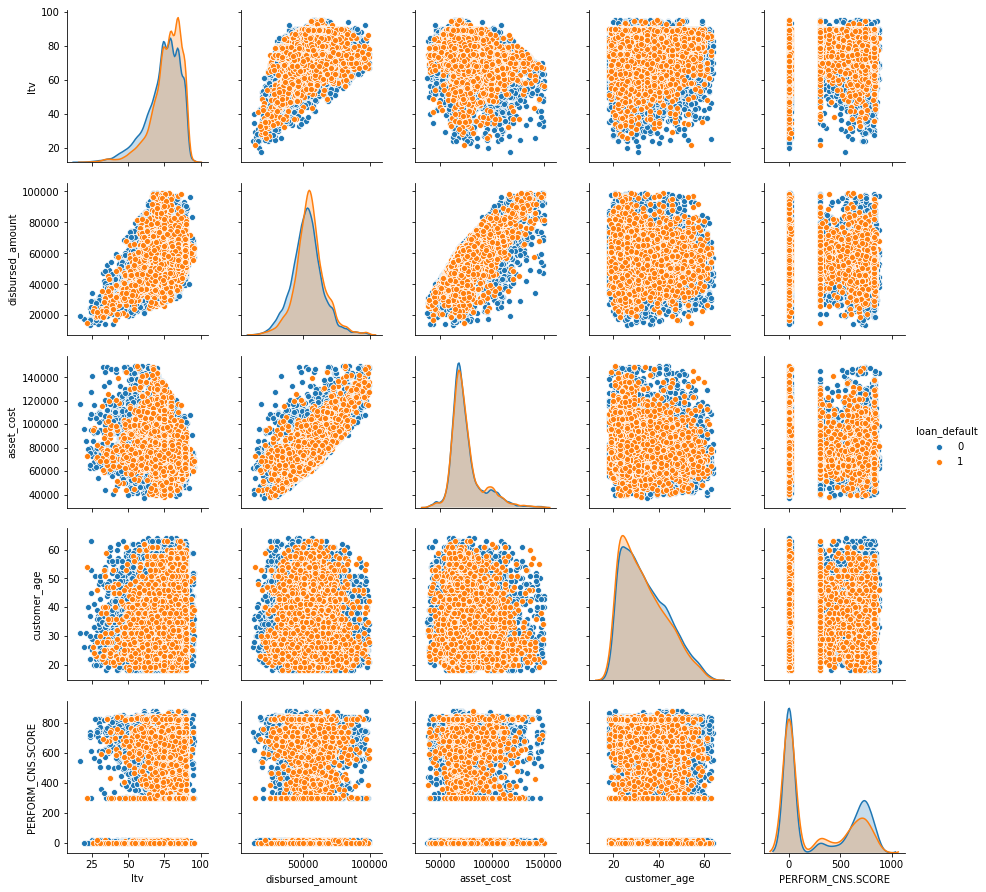

In [30]:
sns.pairplot(filtered_df[list(imp_cols)+['loan_default']],
             hue='loan_default', vars=imp_cols)

Doesn't look like much, but still trying to classify

In [31]:
classifiers = {'K-Means': KMeans(n_jobs=-1),
               'K-Medoids': KMedoids(),
               'Gaussian Mixtures': GaussianMixture()}

In [32]:
n_cl = [2, 3, 4]

In [35]:
np.random.seed(42)

all_scores = {}

for k in (classifiers.keys()):
    cv_scores = {}
    print(k)
    for n in tqdm(n_cl):
        rs = np.zeros(len(folds))
        print('number of clusters: '+str(n))
        for idx, (train_index, test_index) in enumerate((folds), start=0):
            X_train2 = X_train.iloc[train_index, :]
            y_train2 = y_train.iloc[train_index]
            X_test2 = X_train.iloc[test_index, :]
            y_test2 = y_train.iloc[test_index]

            if k != 'Gaussian Mixtures':
                clf = classifiers[k].set_params(n_clusters=n)
            else:
                clf = classifiers[k].set_params(n_components=n)

            clf.fit(X_train2)

            X_train2_f = X_train2.copy()
            X_train2_f['label'] = clf.predict(X_train2)
            X_train2_f = pd.get_dummies(X_train2_f, columns=['label'])
            y_train2_f = y_train2.copy()

            rf.fit(X_train2_f, y_train2_f)

            X_test2_f = X_test2.copy()
            X_test2_f['label'] = clf.predict(X_test2_f)
            X_test2_f = pd.get_dummies(X_test2_f, columns=['label'])
            y_test2_f = y_test2.copy()

            rs[idx] = roc_auc_score(y_test2_f,
                                    rf.predict_proba(X_test2_f)[:, 1])
            print(rs[idx], end=' ')

        cv_scores[n] = np.mean(rs), np.std(rs)
        print('\n'+str(cv_scores[n])+'\n')

    all_scores[k] = cv_scores.copy()

K-Means


number of clusters: 2
0.6313613427461385 0.6427417668538702 0.6549028838441957 0.6228497764170327 0.641368935239294 
(0.6386449410201063, 0.010872560507483598)

number of clusters: 3
0.6300293755330238 0.6400206024507572 0.6565214864409341 0.6201132590166953 0.6417081722556865 
(0.6376785791394195, 0.012196955655185953)

number of clusters: 4
0.6312950108973753 0.6420181741419871 0.6529192965326452 0.6224037614884813 0.6423818514189816 
(0.6382036188958942, 0.010449152938138433)


K-Medoids


number of clusters: 2
0.6304605325499857 0.6442299748565777 0.6554265322964978 0.6218017852107204 0.6415978902574245 
(0.6387033430342413, 0.011594772128587325)

number of clusters: 3
0.6301383492845636 0.6393574040912046 0.6559757529262707 0.6198997473541243 0.6408133297371812 
(0.6372369166786689, 0.011994984621772889)

number of clusters: 4
0.6295010897375155 0.6411789205478109 0.6533394939033604 0.6203388562450722 0.6395061284425664 
(0.6367728977752651, 0.01117401098064858)


Gaussian Mixtures


number of clusters: 2
0.6311582014593007 0.6447245248360379 0.6558920621636386 0.6226132446291169 0.6410524738529774 
(0.6390881013882144, 0.011421955562169326)

number of clusters: 3
0.6314638017625319 0.6436140664144158 0.6571439364880101 0.6231484625433785 0.6412628487518355 
(0.6393266231920343, 0.011516463299958741)

number of clusters: 4
0.6316023879465555 0.6425286773465912 0.657718729295254 0.6243236399422195 0.6391956606431118 
(0.6390738190347464, 0.011251432226361548)




Reference without clustering

In [36]:
for k in all_scores.keys():
    all_scores[k][1] = np.mean(cv0), np.std(cv0)

Plotting everything together

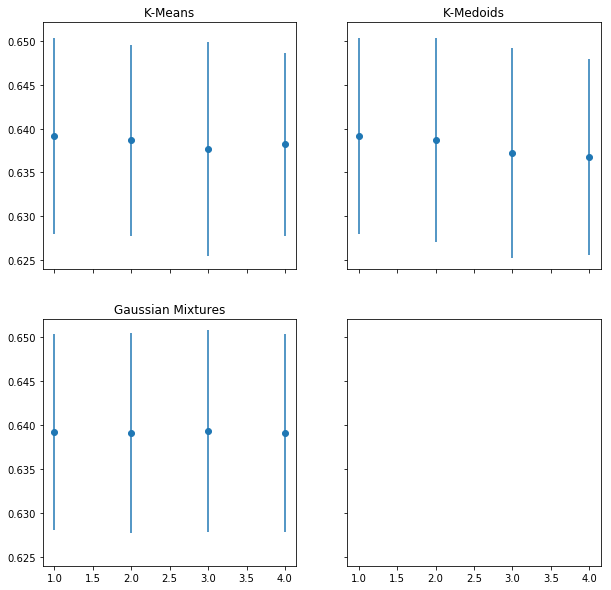

In [37]:
fig, axs = plt.subplots(nrows=2, ncols=2,
                        sharex=True, figsize=(10,10),
                        sharey=True)

for k, ax in zip(all_scores.keys(), axs.flat):
    ax.set_title(f'{k}')
    ax.errorbar(all_scores[k].keys(),
                np.array(list(all_scores[k].values()))[:, 0],
                yerr=np.array(list(all_scores[k].values()))[:, 1],
                fmt='o', label = k)

plt.show()

Looks like the clustering doesn't really affect the scores. Still, choosing GaussianMixture with 3 clusters

In [38]:
clf = GaussianMixture(n_components=3)
clf.fit(filtered_df[features])

GaussianMixture(covariance_type='full', init_params='kmeans', max_iter=100,
                means_init=None, n_components=3, n_init=1, precisions_init=None,
                random_state=None, reg_covar=1e-06, tol=0.001, verbose=0,
                verbose_interval=10, warm_start=False, weights_init=None)

In [39]:
pd.Series(clf.predict(filtered_df[features])).value_counts()

0    12945
1     6270
2     3153
dtype: int64

In [40]:
filtered_df['label'] = clf.predict(filtered_df[features])
filtered_df = pd.get_dummies(filtered_df, columns=['label'])

In [41]:
new_features = filtered_df.columns[(filtered_df.columns != 'loan_default') &
                                   (filtered_df.columns != 'UniqueID')]

In [42]:
rf.fit(filtered_df[new_features], filtered_df['loan_default'])

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
                       max_depth=30, max_features='sqrt', max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=4, min_samples_split=50,
                       min_weight_fraction_leaf=0.0, n_estimators=1000,
                       n_jobs=-1, oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

In [43]:
roc_auc_score(filtered_df['loan_default'],
              rf.predict_proba(filtered_df[new_features])[:, 1])

0.853069867261921

## Results submission

In [44]:
test_df = pd.read_csv('data/test.csv')

In [45]:
proc_test = preprocess(test_df, istrain=False)

In [46]:
proc_test['label'] = clf.predict(proc_test)
proc_test = pd.get_dummies(proc_test, columns=['label'])

In [47]:
diff = set(filtered_df.columns[filtered_df.columns!='loan_default']) -\
    set(proc_test.columns)
diff

{'label_0', 'label_1', 'manufacturer_id_153'}

In [48]:
for c in diff:
    proc_test[c] = [0] * proc_test.shape[0]

In [49]:
proc_test.shape

(23316, 150)

In [50]:
filtered_df.shape

(22368, 151)

In [51]:
y_pred = rf.predict_proba(proc_test.loc[:, 
                                        proc_test.columns!='UniqueID'])[:, 1]

sub_df = pd.concat([proc_test['UniqueID'],
                    pd.Series(y_pred)],
                   axis=1, ignore_index=True)

sub_df.columns = ['UniqueID','loan_default']

In [52]:
sub_df.head()

,UniqueID,loan_default
0,535191,0.190218
1,565698,0.200939
2,536003,0.205369
3,628720,0.163765
4,627276,0.142700


In [53]:
sub_df = sub_df.set_index('UniqueID')

In [54]:
sub_df.to_csv('data/predicted.csv')